In [1]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

/global/homes/s/sferrett/.conda/envs/monsoon-discovery/lib/python3.9/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR = CONFIGS['filepaths']['splits']
LATRANGE  = CONFIGS['domain']['latrange']
LONRANGE  = CONFIGS['domain']['lonrange']
SPLIT     = 'valid'

In [3]:
# Load z-score stats
with open(os.path.join(SPLITSDIR, 'stats.json'), 'r', encoding='utf-8') as f:
    stats = json.load(f)

# Load normalized (z-scored) split
with xr.open_dataset(os.path.join(SPLITSDIR, f'norm_{SPLIT}.h5'), engine='h5netcdf') as ds:
    # lf is static (no time dim); shf varies with time
    lf_z  = ds['lf'].load()   # (lat, lon) or (time, lat, lon)
    shf_z = ds['shf'].load()  # (time, lat, lon)
    lat   = ds['lat'].values
    lon   = ds['lon'].values

# If lf has no time dimension, broadcast to match shf
if 'time' not in lf_z.dims:
    lf_z_full = lf_z.expand_dims(time=shf_z.time).broadcast_like(shf_z)
else:
    lf_z_full = lf_z

print('lf_z dims:', lf_z.dims, '| shape:', lf_z.shape)
print('shf_z dims:', shf_z.dims, '| shape:', shf_z.shape)
print(f'lf_z  range: [{float(lf_z.min()):.2f}, {float(lf_z.max()):.2f}]')
print(f'shf_z range: [{float(shf_z.min()):.2f}, {float(shf_z.max()):.2f}]')
print(f'lf  mean={stats.get("lf_mean","N/A"):.3f}  std={stats.get("lf_std","N/A"):.3f}')
print(f'shf mean={stats.get("shf_mean","N/A"):.3f}  std={stats.get("shf_std","N/A"):.3f}')

lf_z dims: ('lat', 'lon') | shape: (21, 31)
shf_z dims: ('lat', 'lon', 'time') | shape: (21, 31, 2208)
lf_z  range: [-0.66, 1.60]
shf_z range: [-11.67, 3.24]
lf  mean=0.293  std=0.441
shf mean=-13.909  std=42.259


In [4]:
# Compute derived quantities at each (time, lat, lon)
max_term = xr.apply_ufunc(np.maximum, lf_z_full, shf_z)   # max(lf_z, shf_z)
abs_term = abs(lf_z_full - shf_z)                          # abs(lf_z - shf_z)
lf_wins  = (lf_z_full > shf_z).astype(float)              # 1 where lf dominates

# Time-average each quantity
lf_z_mean   = lf_z if 'time' not in lf_z.dims else lf_z.mean('time')
shf_z_mean  = shf_z.mean('time')
max_mean     = max_term.mean('time')
abs_mean     = abs_term.mean('time')
lf_wins_frac = lf_wins.mean('time')  # fraction of time steps where lf_z > shf_z

# Native-unit time means for reference
lf_mean_val  = stats.get('lf_mean',  0.0)
lf_std_val   = stats.get('lf_std',   1.0)
shf_mean_val = stats.get('shf_mean', 0.0)
shf_std_val  = stats.get('shf_std',  1.0)

lf_native  = lf_z_mean  * lf_std_val  + lf_mean_val
shf_native = shf_z_mean * shf_std_val + shf_mean_val

print('Time-mean lf_z:', float(lf_z_mean.mean()), '(should be ~0 if static with zero mean after z-score)')
print('Time-mean shf_z:', float(shf_z_mean.mean()))

Time-mean lf_z: -7.031700022253062e-08 (should be ~0 if static with zero mean after z-score)
Time-mean shf_z: 0.013705512508749962


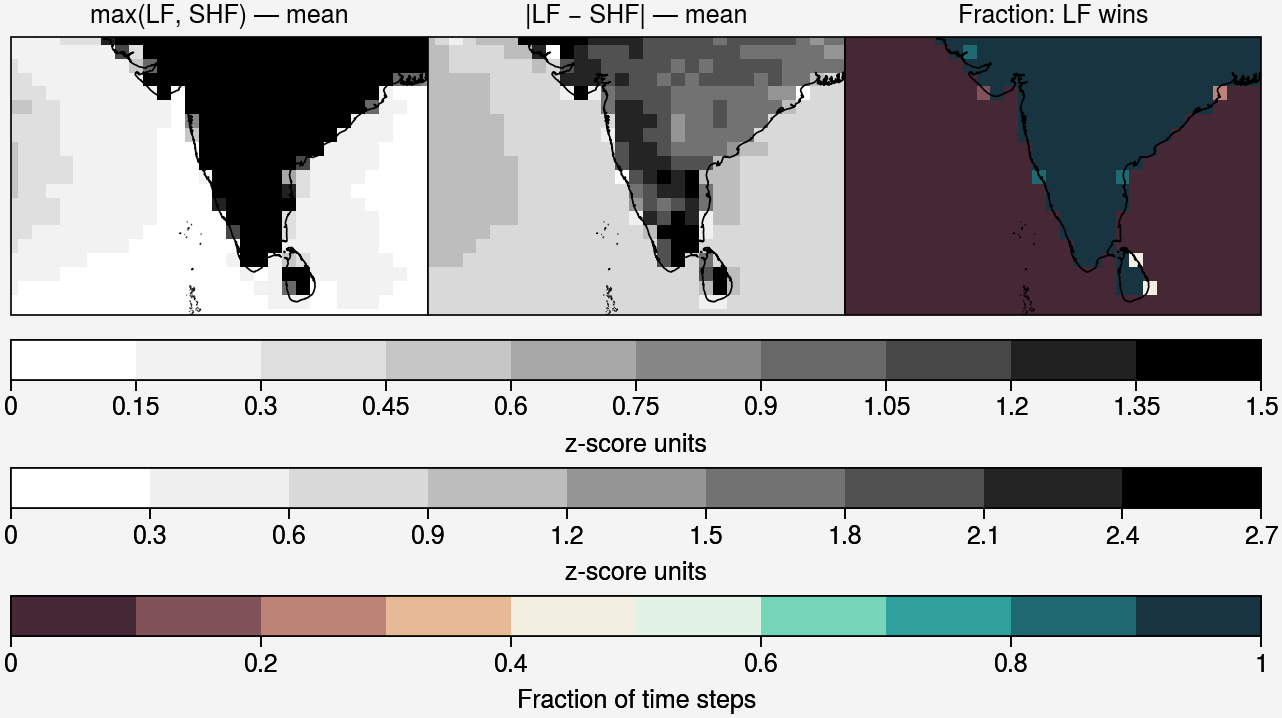

In [5]:
# ── SR-HI surface term + dominance map ────────────────────────────────────────
fig, axs = pplt.subplots(nrows=1, ncols=3, proj='cyl', figwidth=6.5, share=False, wspace=0)
axs.format(coast=True, borders=False, latlim=LATRANGE, lonlim=LONRANGE,
           latlines=5, lonlines=5, grid=False)

vmax_max = float(max_mean.quantile(0.99))
m1 = axs[0].pcolormesh(max_mean.lon, max_mean.lat, max_mean,
                        cmap='Grays', vmin=0, vmax=vmax_max, levels=11)
axs[0].format(title='max(LF, SHF) — mean',)
fig.colorbar(m1, loc='b', label='z-score units')

vmax_abs = float(abs_mean.quantile(0.99))
m2 = axs[1].pcolormesh(abs_mean.lon, abs_mean.lat, abs_mean,
                        cmap='Grays', vmin=0, vmax=vmax_abs, levels=11)
axs[1].format(title='|LF − SHF| — mean', )
fig.colorbar(m2, loc='b', label='z-score units')

m3 = axs[2].pcolormesh(lf_wins_frac.lon, lf_wins_frac.lat, lf_wins_frac,
                        cmap='DryWet', vmin=0, vmax=1, levels=11)
axs[2].format(title='Fraction: LF wins',)
fig.colorbar(m3, loc='b', label='Fraction of time steps', ticks=0.2)

pplt.show()
# fig.save('../figs/surface_terms_derived.jpg')